# 3. Modelado
**Autores:** Eduardo Estefanía Ovejero, David Blasco Tena y Alejandro Jesús Castro García

Origen de los datos: https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset

## Objetivo
El objetivo de este notebook es entrenar y evaluar un modelo de aprendizaje automático capaz de predecir si un empleado abandonará la empresa (`Attrition`) a partir de las variables previamente preparadas en la fase de *Feature Engineering*.

En esta fase se realizará:
- La carga de los conjuntos de entrenamiento y prueba ya transformados
- La aplicación de una técnica de balanceo de clases (**SMOTE**) exclusivamente sobre el conjunto de entrenamiento
- El entrenamiento de un modelo de **Regresión logistica**.
- La generación de predicciones sobre el conjunto de prueba
- La evaluación del modelo mediante métricas apropiadas para un problema de clasificación binaria con desbalanceo de clases.

## 3.1. Importación de librerias y carga de datos
Se cargan los conjuntos de entrenamiento y prueba generados en el notebook anterior.
Estos datos ya han sido codificados y escalados, por lo que están listos para la fase de modelado.

Antes del entrenamiento, se comprobará la distribución de la variable objetivo en el conjunto de entrenamiento para justificar la necesidad de aplicar técnicas de balanceo.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    balanced_accuracy_score
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

In [2]:
X_train = pd.read_csv("X_train_escalado.csv")
X_test = pd.read_csv("X_test_escalado.csv")
y_train = pd.read_csv("y_train.csv").squeeze()
y_test = pd.read_csv("y_test.csv").squeeze()

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1176, 39)
X_test: (294, 39)
y_train: (1176,)
y_test: (294,)


In [3]:
print("Distribución de clases en y_train:")
print(y_train.value_counts())

print("\nDistribución porcentual:")
print((y_train.value_counts(normalize=True) * 100).round(2))

Distribución de clases en y_train:
Attrition
0    986
1    190
Name: count, dtype: int64

Distribución porcentual:
Attrition
0    83.84
1    16.16
Name: proportion, dtype: float64


# 3.2. Elección de Métricas de Evaluación

## Problemática del Desbalance de Clases

En problemas de abandono empresarial, típicamente existe un **fuerte desbalance**:
- La mayoría de empleados **NO abandonan** (clase mayoritaria)
- Solo una minoría **SÍ abandona** (clase minoritaria - nuestra clase de interés)

### ¿Por qué NO usar Accuracy convencional?

La **accuracy** simple puede ser engañosa en datos desbalanceados:

**Ejemplo:** Si solo el 15% de empleados abandonan:
- Un modelo que **siempre prediga "No abandona"** obtendría 85% de accuracy
- Pero sería **completamente inútil** para detectar empleados en riesgo

### Métrica Principal: Balanced Accuracy

**Balanced Accuracy** = (Sensibilidad + Especificidad) / 2

Promedia el rendimiento en **ambas clases**, por lo que:
- No se ve sesgada por el desbalance
- Penaliza modelos que ignoran la clase minoritaria
- Valora equitativamente la detección de ambos grupos

### Métricas Complementarias

1. **Precision (abandono):** De los que predecimos que abandonan, ¿cuántos realmente lo hacen?
   - Alta precisión → Pocas falsas alarmas
   - Importante para no desperdiciar recursos en intervenciones innecesarias

2. **Recall (abandono):** De los que realmente abandonan, ¿cuántos detectamos?
   - Alto recall → Detectamos la mayoría de casos de riesgo
   - Crítico para no perder empleados valiosos

3. **F1-Score (abandono):** Media armónica de precision y recall
   - Balance entre ambas métricas
   - Útil cuando queremos optimizar ambas simultáneamente

## 3.3. Entenamiento de los modelos

### ¿Qué es un Pipeline?

Un **Pipeline** es un objeto que encadena múltiples pasos de procesamiento de datos y el entrenamiento del modelo en un solo flujo de trabajo ininterrumpible. 

### ¿Por qué usar un Pipeline?

1. **Prevención de Fuga de Datos (Data Leakage):** Esta es la razón más importante. Al usar Validación Cruzada (Cross-Validation), el Pipeline garantiza que transformaciones como el escalado o **SMOTE** se calculen *únicamente* con los datos de entrenamiento de ese pliegue (fold) específico, dejando el pliegue de validación completamente ciego y puro. Si hiciéramos esto manualmente antes de dividir los datos, el modelo haría trampa.

2. **Código Limpio y Organizado:** Reemplaza docenas de líneas de código dispersas (hacer `.fit()` y `.transform()` repetidamente) por un solo objeto unificado. Reduce drásticamente los errores humanos.

3. **Optimización Global (GridSearchCV):** Nos permite buscar los mejores hiperparámetros no solo para el algoritmo (ej. la `C` en Regresión Logística), sino también para los pasos previos al mismo tiempo (ej. probar si es mejor seleccionar 10 o 15 variables con `SelectKBest`).

4. **Facilidad de Puesta en Producción (Deployment):** Cuando terminas el proyecto, no exportas solo el modelo matemático, exportas el Pipeline entero. Así, cuando llega un empleado nuevo, el Pipeline sabe exactamente cómo escalar y procesar sus datos automáticamente antes de predecir si va a renunciar.

### ¿Qué es SMOTE?

**SMOTE (Synthetic Minority Over-sampling Technique)** es una técnica de balanceo de clases que:
1. Genera **ejemplos sintéticos** de la clase minoritaria (empleados que abandonan)
2. Crea nuevos puntos interpolando entre ejemplos existentes cercanos
3. Balancea el dataset sin duplicar observaciones reales

### ¿Por qué usar SMOTE?

**Sin SMOTE:**
- El modelo aprende principalmente de la clase mayoritaria
- Tiende a predecir "No abandona" para casi todos los casos
- Baja precision y recall para detectar abandono real

**Con SMOTE:**
- El modelo ve igual cantidad de ejemplos de ambas clases
- Aprende mejor los patrones de empleados en riesgo
- Mejora significativa en precision y recall de la clase minoritaria
- Reduce sesgo hacia la clase mayoritaria

### Integración en Pipeline: Ventaja Clave

Al incluir SMOTE dentro de la Pipeline:
- Se aplica **automáticamente en cada fold de validación cruzada**
- **NUNCA se aplica a datos de test** → evita data leakage
- El balanceo se hace solo con datos de entrenamiento de cada fold
- Garantiza evaluación realista del rendimiento

In [4]:
#
# 1. Creación de la rejilla de hiperparámetros con SMOTE integrado.
#
ml_pipe = Pipeline([
    ('smote', SMOTE(random_state=42)),  # SMOTE integrado en la pipeline
    ('seleccion', SelectKBest(score_func=f_classif)),
    ('classifier', None)]
)

# Grid de hiperparámetros (sin class_weight='balanced' ya que SMOTE balancea)
# Grid de hiperparámetros (versión extendida para búsqueda más exhaustiva)
grid = [
    # Logistic Regression
    {
        'seleccion__k': [10, 15, 20, 25, 'all'],
        'classifier': [LogisticRegression(random_state=42)],
        'classifier__solver': ['lbfgs', 'liblinear', 'saga'],
        'classifier__C': [0.01, 0.1, 1.0, 10.0, 100.0],
    },
    # Se puden poner más algoritmos
]

print(f"Total de configuraciones en el grid: {len(grid)} algoritmos diferentes")
print("Pipeline con SMOTE integrado para balanceo automático de clases")

#
# 2. Búsqueda de hiperparámetros.
#
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
search = GridSearchCV(
    ml_pipe, 
    grid, 
    scoring='balanced_accuracy',  # Métrica apropiada para clases desbalanceadas
    cv=cv,
    n_jobs=-1,  # Usar todos los cores disponibles
    verbose=2
)

print("Iniciando búsqueda de hiperparámetros con SMOTE...")
search.fit(X_train, y_train)
print("\n¡Búsqueda completada!")

Total de configuraciones en el grid: 1 algoritmos diferentes
Pipeline con SMOTE integrado para balanceo automático de clases
Iniciando búsqueda de hiperparámetros con SMOTE...
Fitting 5 folds for each of 75 candidates, totalling 375 fits

¡Búsqueda completada!


## 3.5 Análisis Comparativo de Resultados

Esta sección presenta:
1. **Ranking de modelos:** Ordenados por rendimiento (Balanced Accuracy)
2. **Top 10 mejores configuraciones:** Identificación de los mejores hiperparámetros
3. **Análisis por algoritmo:** Rendimiento promedio de cada tipo de modelo (si los hubiera)
4. **Visualizaciones:** Gráficos comparativos de rendimiento
5. **Estadísticas globales:** Rango de rendimiento y configuraciones totales evaluadas

El análisis permite identificar:
- Qué algoritmo funciona mejor para este problema específico
- Qué familias de modelos son más prometedoras
- La variabilidad del rendimiento según hiperparámetros
- Si hay overfitting o underfitting significativo

Top 10 mejores modelos:


,classifier,mean_test_score,std_test_score,rank_test_score
0,LogisticRegression,0.743073,0.024603,1
1,LogisticRegression,0.730447,0.025588,2
2,LogisticRegression,0.730141,0.033726,3
3,LogisticRegression,0.728392,0.017851,4
4,LogisticRegression,0.728318,0.020362,5
5,LogisticRegression,0.728318,0.020362,5
6,LogisticRegression,0.727884,0.017849,7
7,LogisticRegression,0.724469,0.030982,8
8,LogisticRegression,0.724469,0.030982,8
9,LogisticRegression,0.715675,0.036639,10



Mejor modelo: LogisticRegression
Mejor score (Balanced Accuracy): 0.7431
Mejores parámetros: {'classifier': LogisticRegression(random_state=42), 'classifier__C': 0.1, 'classifier__solver': 'liblinear', 'seleccion__k': 'all'}

ANÁLISIS POR ALGORITMO

Rendimiento promedio por algoritmo:


,Promedio,Desv_Std,Mejor,Configuraciones
classifier,,,,
LogisticRegression,0.671,0.0328,0.7431,75


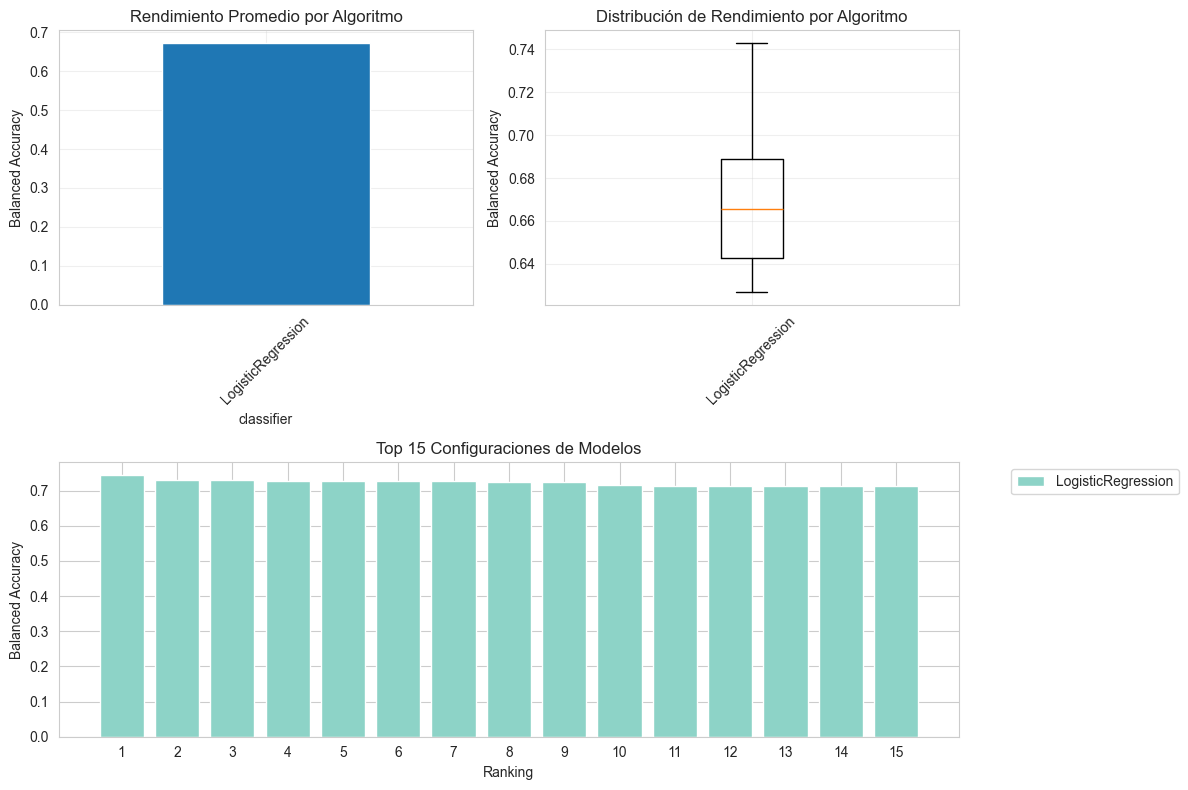


ESTADÍSTICAS FINALES DE LA BÚSQUEDA
Total de configuraciones evaluadas: 75
Mejor balanced accuracy: 0.7431
Peor balanced accuracy: 0.6266
Rango de rendimiento: 0.1164
Algoritmo ganador: LogisticRegression


In [5]:
# Obtenemos el dataframe con los resultados.
results = pd.DataFrame(search.cv_results_)

# Simplificamos los nombres de las columnas.
results.rename(columns=lambda s : s.replace('classifier__', ''), inplace=True)
results.rename(columns=lambda s : s.replace('param_classifier', 'classifier'), inplace=True)

# Extraemos el nombre del clasificador
results['classifier'] = results.classifier.apply(lambda c : c.__class__.__name__)

# Eliminamos columnas redundantes
results.drop(columns=['params'], inplace=True)

# Ordenamos por ranking de mejor a peor
results.sort_values(by='rank_test_score', inplace=True)
results.reset_index(inplace=True, drop=True)

# Mostramos los mejores modelos
print("Top 10 mejores modelos:")
top_results = results[['classifier', 'mean_test_score', 'std_test_score', 'rank_test_score']].head(10)
display(top_results)

print(f"\nMejor modelo: {search.best_estimator_['classifier'].__class__.__name__}")
print(f"Mejor score (Balanced Accuracy): {search.best_score_:.4f}")
print(f"Mejores parámetros: {search.best_params_}")

# Análisis por algoritmo - rendimiento promedio de cada tipo de modelo
print("\n" + "="*60)
print("ANÁLISIS POR ALGORITMO")
print("="*60)

algorithm_performance = results.groupby('classifier').agg({
    'mean_test_score': ['mean', 'std', 'max', 'count']
}).round(4)

algorithm_performance.columns = ['Promedio', 'Desv_Std', 'Mejor', 'Configuraciones']
algorithm_performance = algorithm_performance.sort_values('Promedio', ascending=False)

print("\nRendimiento promedio por algoritmo:")
display(algorithm_performance)

# Visualización del rendimiento
plt.figure(figsize=(12, 8))

# Gráfico de barras del rendimiento promedio
plt.subplot(2, 2, 1)
algorithm_performance['Promedio'].plot(kind='bar')
plt.title('Rendimiento Promedio por Algoritmo')
plt.ylabel('Balanced Accuracy')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Box plot del rendimiento por algoritmo
plt.subplot(2, 2, 2)
algorithms = results['classifier'].unique()
data_for_boxplot = [results[results['classifier'] == alg]['mean_test_score'].values for alg in algorithms]
plt.boxplot(data_for_boxplot, labels=algorithms)
plt.title('Distribución de Rendimiento por Algoritmo')
plt.ylabel('Balanced Accuracy')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Top 15 configuraciones
plt.subplot(2, 1, 2)
top_15 = results.head(15)
colors = plt.cm.Set3(np.linspace(0, 1, len(top_15['classifier'].unique())))
color_map = dict(zip(top_15['classifier'].unique(), colors))
bar_colors = [color_map[alg] for alg in top_15['classifier']]

bars = plt.bar(range(len(top_15)), top_15['mean_test_score'], color=bar_colors)
plt.title('Top 15 Configuraciones de Modelos')
plt.xlabel('Ranking')
plt.ylabel('Balanced Accuracy')
plt.xticks(range(len(top_15)), [f"{i+1}" for i in range(len(top_15))])

# Añadir leyenda
unique_algs = top_15['classifier'].unique()
legend_elements = [plt.Rectangle((0,0),1,1, facecolor=color_map[alg], label=alg) for alg in unique_algs]
plt.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Estadísticas finales
total_configs = len(results)
best_score = results['mean_test_score'].max()
worst_score = results['mean_test_score'].min()
print(f"\n" + "="*60)
print("ESTADÍSTICAS FINALES DE LA BÚSQUEDA")
print("="*60)
print(f"Total de configuraciones evaluadas: {total_configs}")
print(f"Mejor balanced accuracy: {best_score:.4f}")
print(f"Peor balanced accuracy: {worst_score:.4f}")
print(f"Rango de rendimiento: {best_score - worst_score:.4f}")
print(f"Algoritmo ganador: {search.best_estimator_['classifier'].__class__.__name__}")

### Conclusiones de la Mejor Configuración 

El modelo con mejor rendimiento ha sido la Regresión Logística, alcanzando una balanced accuracy de 0.7431. Los mejores resultados se concentran en un rango estrecho, lo que indica estabilidad del modelo frente a cambios de hiperparámetros. La configuración óptima utiliza C = 0.1, solver = liblinear y todas las variables disponibles, por lo que la selección de características no mejora el rendimiento en este caso. En conjunto, el modelo ofrece una capacidad predictiva razonable.

## 3.6. Evaluación del Modelo e Impacto Empresarial

Esta sección presenta:
1. **Métricas en conjunto de prueba (Test):** Rendimiento definitivo del modelo campeón sobre datos nunca antes vistos (Balanced Accuracy, Precision, Recall, F1-Score).
2. **Matriz de Confusión:** Desglose exacto de los aciertos y los tipos de errores (Verdaderos/Falsos Positivos y Negativos).
3. **Traducción a negocio (Costos):** Impacto financiero de las predicciones, comparando el costo de una falsa alarma (Falso Positivo) frente al costo de una fuga sorpresa (Falso Negativo).
4. **Interpretación estratégica:** Plan de acción sobre cómo utilizar estos resultados en el día a día del departamento de Recursos Humanos.

La evaluación permite identificar:
- Cuántas fugas de talento reales somos capaces de predecir y prevenir a tiempo.
- El nivel de fiabilidad (tasa de falsas alarmas) al que se enfrenta RRHH cuando el modelo alerta sobre un empleado en riesgo.
- El balance costo-beneficio de implementar políticas de retención proactivas basadas en el algoritmo.
- El límite o "techo" predecible del comportamiento humano utilizando la información corporativa actual.

In [6]:
# Rendimiento en validación cruzada
acc_val = search.best_score_
print(f'Balanced Accuracy en validación: {(100 * acc_val):.2f}%')

# Predicciones en test
y_pred = search.predict(X_test)

# Métricas en test
balanced_acc_test = balanced_accuracy_score(y_test, y_pred)
precision_test = precision_score(y_test, y_pred, pos_label=1)  # 1 = 'Yes' (abandono)
recall_test = recall_score(y_test, y_pred, pos_label=1)
f1_test = f1_score(y_test, y_pred, pos_label=1)

print(f'\n=== MÉTRICAS EN TEST ===')
print(f'Balanced Accuracy: {(100 * balanced_acc_test):.2f}%')
print(f'Precision (abandono): {(100 * precision_test):.2f}%')
print(f'Recall (abandono): {(100 * recall_test):.2f}%')
print(f'F1-Score (abandono): {(100 * f1_test):.2f}%')

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
print(f'\nMatriz de Confusión:')
print(f'                 Predicción')
print(f'Real      No    Yes')
print(f'No     {cm[0,0]:4d}  {cm[0,1]:4d}')
print(f'Yes    {cm[1,0]:4d}  {cm[1,1]:4d}')

# Interpretación empresarial
print(f'\n=== INTERPRETACIÓN EMPRESARIAL ===')
print(f'Empleados correctamente identificados como "se quedan": {cm[0,0]}')
print(f'Empleados correctamente identificados como "abandonan": {cm[1,1]}')
print(f'Falsos positivos (predice abandono, pero se queda): {cm[0,1]}')
print(f'Falsos negativos (predice que se queda, pero abandona): {cm[1,0]}')

# Reporte completo
print(f'\n=== REPORTE DETALLADO ===')
target_names = ['No abandona', 'Abandona']
print(classification_report(y_test, y_pred, target_names=target_names))

Balanced Accuracy en validación: 74.31%

=== MÉTRICAS EN TEST ===
Balanced Accuracy: 69.46%
Precision (abandono): 44.44%
Recall (abandono): 51.06%
F1-Score (abandono): 47.52%

Matriz de Confusión:
                 Predicción
Real      No    Yes
No      217    30
Yes      23    24

=== INTERPRETACIÓN EMPRESARIAL ===
Empleados correctamente identificados como "se quedan": 217
Empleados correctamente identificados como "abandonan": 24
Falsos positivos (predice abandono, pero se queda): 30
Falsos negativos (predice que se queda, pero abandona): 23

=== REPORTE DETALLADO ===
              precision    recall  f1-score   support

 No abandona       0.90      0.88      0.89       247
    Abandona       0.44      0.51      0.48        47

    accuracy                           0.82       294
   macro avg       0.67      0.69      0.68       294
weighted avg       0.83      0.82      0.82       294



### Conclusiones

1. El modelo final (Regresión Logística con SMOTE) muestra un rendimiento aceptable pero mejorable para predecir abandono: obtuvo 74.31% de balanced accuracy en validación cruzada y 69.46% en test.

2. La diferencia entre validación y test (caída de ~4.85 puntos) sugiere una pérdida moderada de generalización, por lo que los resultados son útiles, aunque no totalmente estables fuera del entrenamiento.

3. En la clase de interés (Abandona), el modelo logra Recall = 51.06% y Precision = 44.44%. Esto implica que detecta aproximadamente la mitad de los casos reales de fuga, pero con una proporción relevante de falsas alarmas.

4. La matriz de confusión confirma un equilibrio de errores en la clase positiva: 23 falsos negativos (riesgos no detectados) y 30 falsos positivos (alertas innecesarias). Desde negocio, ambos errores tienen coste y deben ponderarse según la estrategia de RRHH.

5. La accuracy global (82%) no debe usarse como métrica principal por el desbalance de clases; balanced accuracy, recall, precision y F1 describen mejor la utilidad real del modelo.

6. En conjunto, el sistema puede servir como herramienta de apoyo a la decisión, no como sustituto del criterio humano. Su valor está en priorizar perfiles con mayor riesgo de abandono para intervención temprana.